# ------------EMPLOYEE ATTRITION ANALYSIS------------

### Objective: Analyze employee attrition and identifying important factors affecting resignation.

### Importing Dependencies :

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

### Data Ingestion :

In [2]:
df=pd.read_csv("Emp_Attrition.csv")

### Data Understanding : 

In [3]:
df.head()

,Employee ID,Age,Gender,Years at Company,Job Role,Monthly Income,Work-Life Balance,Job Satisfaction,Performance Rating,Number of Promotions,...,Number of Dependents,Job Level,Company Size,Company Tenure (In Months),Remote Work,Leadership Opportunities,Innovation Opportunities,Company Reputation,Employee Recognition,Attrition
0,8410,31,Male,19,Education,5390,Excellent,Medium,Average,2,...,0,Mid,Medium,89.0,No,No,No,Excellent,Medium,Stayed
1,64756,59,Female,4,Media,5534,Poor,High,Low,3,...,3,Mid,Medium,21.0,No,No,No,Fair,Low,Stayed
2,30257,24,Female,10,Healthcare,8159,Good,High,Low,0,...,3,Mid,Medium,74.0,No,No,No,Poor,Low,Stayed
3,65791,36,Female,7,Education,3989,Good,High,High,1,...,2,Mid,Small,50.0,Yes,No,No,Good,Medium,Stayed
4,65026,56,Male,41,Education,4821,Fair,Very High,Average,0,...,0,Senior,Medium,68.0,No,No,No,Fair,Medium,Stayed


In [4]:
df.sample(5)

,Employee ID,Age,Gender,Years at Company,Job Role,Monthly Income,Work-Life Balance,Job Satisfaction,Performance Rating,Number of Promotions,...,Number of Dependents,Job Level,Company Size,Company Tenure (In Months),Remote Work,Leadership Opportunities,Innovation Opportunities,Company Reputation,Employee Recognition,Attrition
21257,35969,51,Male,33,Healthcare,8495,Fair,High,Average,2,...,4,Mid,Large,102.0,No,Yes,Yes,Fair,High,Stayed
27088,17648,53,Female,15,Technology,7648,Fair,Very High,Below Average,3,...,0,Senior,Small,66.0,No,No,No,Fair,Low,Stayed
56587,20133,31,Male,23,Finance,9435,Good,High,High,0,...,5,Mid,Medium,47.0,Yes,No,No,Good,Low,Stayed
48936,73414,38,Female,6,Finance,7110,Excellent,High,Average,0,...,1,Mid,Small,18.0,Yes,No,No,Good,Low,Stayed
44811,23405,40,Female,13,Finance,7195,Fair,High,High,2,...,0,Mid,Medium,17.0,Yes,No,No,Excellent,Low,Stayed


In [5]:
df.shape

(74610, 24)

In [6]:
df.columns

Index(['Employee ID', 'Age', 'Gender', 'Years at Company', 'Job Role',
       'Monthly Income', 'Work-Life Balance', 'Job Satisfaction',
       'Performance Rating', 'Number of Promotions', 'Overtime',
       'Distance from Home', 'Education Level', 'Marital Status',
       'Number of Dependents', 'Job Level', 'Company Size',
       'Company Tenure (In Months)', 'Remote Work', 'Leadership Opportunities',
       'Innovation Opportunities', 'Company Reputation',
       'Employee Recognition', 'Attrition'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74610 entries, 0 to 74609
Data columns (total 24 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Employee ID                 74610 non-null  int64  
 1   Age                         74610 non-null  int64  
 2   Gender                      74610 non-null  object 
 3   Years at Company            74610 non-null  int64  
 4   Job Role                    74610 non-null  object 
 5   Monthly Income              74610 non-null  int64  
 6   Work-Life Balance           74610 non-null  object 
 7   Job Satisfaction            74610 non-null  object 
 8   Performance Rating          74610 non-null  object 
 9   Number of Promotions        74610 non-null  int64  
 10  Overtime                    74610 non-null  object 
 11  Distance from Home          72698 non-null  float64
 12  Education Level             74610 non-null  object 
 13  Marital Status              746

In [8]:
df.describe()


,Employee ID,Age,Years at Company,Monthly Income,Number of Promotions,Distance from Home,Number of Dependents,Company Tenure (In Months)
count,74610.000000,74610.000000,74610.000000,74610.000000,74610.000000,72698.000000,74610.000000,72197.000000
mean,37246.028696,38.529379,15.722638,7344.931417,0.832958,49.990839,1.657432,55.711899
std,21505.785344,12.082299,11.224059,2596.373589,0.995326,28.519135,1.579862,25.392325
min,1.000000,18.000000,1.000000,1226.000000,0.000000,1.000000,0.000000,2.000000
25%,18624.250000,28.000000,7.000000,5652.000000,0.000000,25.000000,0.000000,36.000000
50%,37239.500000,39.000000,13.000000,7348.500000,1.000000,50.000000,1.000000,56.000000
75%,55871.750000,49.000000,23.000000,8876.000000,2.000000,75.000000,3.000000,76.000000
max,74498.000000,59.000000,51.000000,50030.000000,4.000000,99.000000,15.000000,128.000000


In [9]:
df.describe(include="object")

,Gender,Job Role,Work-Life Balance,Job Satisfaction,Performance Rating,Overtime,Education Level,Marital Status,Job Level,Company Size,Remote Work,Leadership Opportunities,Innovation Opportunities,Company Reputation,Employee Recognition,Attrition
count,74610,74610,74610,74610,74610,74610,74610,74610,74610,74610,74610,74610,74610,74610,74610,74610
unique,2,5,4,4,4,2,5,3,3,3,2,2,2,4,4,2
top,Male,Technology,Good,High,Average,No,Bachelorâ€™s Degree,Married,Entry,Medium,No,No,No,Good,Low,Stayed
freq,40898,19350,28196,37306,44786,50230,22365,37470,29820,37281,60390,70952,62486,37241,29654,39191


### Data Cleaning :

In [10]:
df.drop("Employee ID",axis=1,inplace=True)

In [11]:
df.columns=df.columns.str.replace(" ","_")

In [12]:
df.columns=df.columns.str.lower()

In [13]:
df["education_level"] = df["education_level"].replace(
                  {"Masterâ€™s Degree": "Master's Degree",
                    "Bachelorâ€™s Degree": "Bachelor's Degree"
})

In [14]:
# Finding Missing Values

df.isnull().sum()


age                              0
gender                           0
years_at_company                 0
job_role                         0
monthly_income                   0
work-life_balance                0
job_satisfaction                 0
performance_rating               0
number_of_promotions             0
overtime                         0
distance_from_home            1912
education_level                  0
marital_status                   0
number_of_dependents             0
job_level                        0
company_size                     0
company_tenure_(in_months)    2413
remote_work                      0
leadership_opportunities         0
innovation_opportunities         0
company_reputation               0
employee_recognition             0
attrition                        0
dtype: int64

In [15]:
df.duplicated().sum()

np.int64(112)

In [16]:
df.drop_duplicates(inplace=True)

In [17]:
df.dtypes

age                             int64
gender                         object
years_at_company                int64
job_role                       object
monthly_income                  int64
work-life_balance              object
job_satisfaction               object
performance_rating             object
number_of_promotions            int64
overtime                       object
distance_from_home            float64
education_level                object
marital_status                 object
number_of_dependents            int64
job_level                      object
company_size                   object
company_tenure_(in_months)    float64
remote_work                    object
leadership_opportunities       object
innovation_opportunities       object
company_reputation             object
employee_recognition           object
attrition                      object
dtype: object

<Axes: xlabel='distance_from_home', ylabel='Count'>

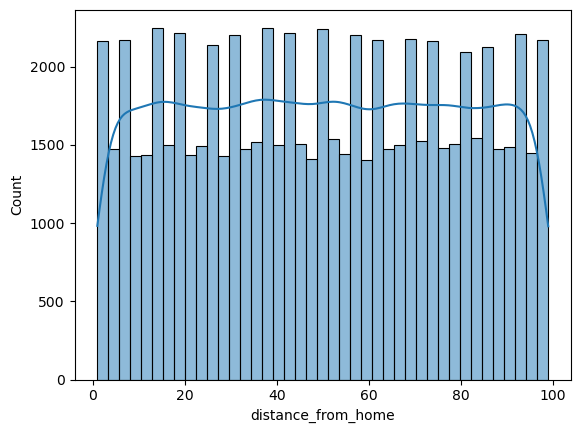

In [18]:
sns.histplot(df["distance_from_home"],kde=True)

In [19]:
df["distance_from_home"].fillna(df["distance_from_home"].median(),inplace=True)

<Axes: xlabel='company_tenure_(in_months)', ylabel='Count'>

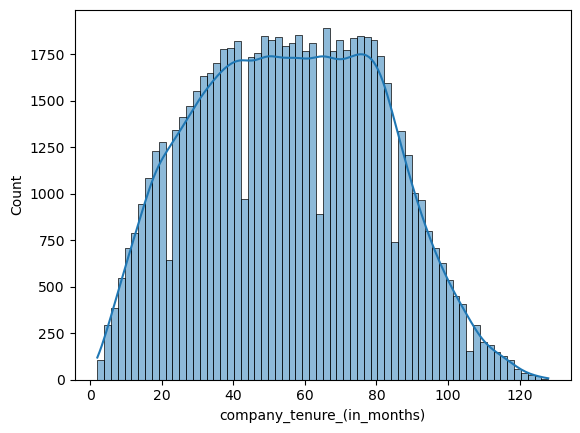

In [20]:
sns.histplot(df["company_tenure_(in_months)"],kde=True)

In [21]:
df["company_tenure_(in_months)"].fillna(df["company_tenure_(in_months)"].median(),inplace=True)

In [22]:
df.isnull().sum()

age                           0
gender                        0
years_at_company              0
job_role                      0
monthly_income                0
work-life_balance             0
job_satisfaction              0
performance_rating            0
number_of_promotions          0
overtime                      0
distance_from_home            0
education_level               0
marital_status                0
number_of_dependents          0
job_level                     0
company_size                  0
company_tenure_(in_months)    0
remote_work                   0
leadership_opportunities      0
innovation_opportunities      0
company_reputation            0
employee_recognition          0
attrition                     0
dtype: int64

### Feature Engineering :

In [23]:
 # Create EDA Features (Optional)
# These are only for graphs.
df["age_group"] = pd.cut(
    df["age"],
    bins=[18,25,35,45,60],
    labels=["18-25","26-35","36-45","46-60"]
)

df["salary_category"] = pd.cut(
    df["monthly_income"],
    bins=3,
    labels=["Low","Medium","High"]
)

In [24]:
pd.pivot_table(
    df,
    index="job_role",
    columns="gender",
    values="monthly_income",
    aggfunc="mean"
)

gender,Female,Male
job_role,,
Education,4489.693094,4502.522738
Finance,8573.708688,8607.073192
Healthcare,8005.840047,8024.275965
Media,5995.922068,5989.222632
Technology,9224.144150,9226.065433


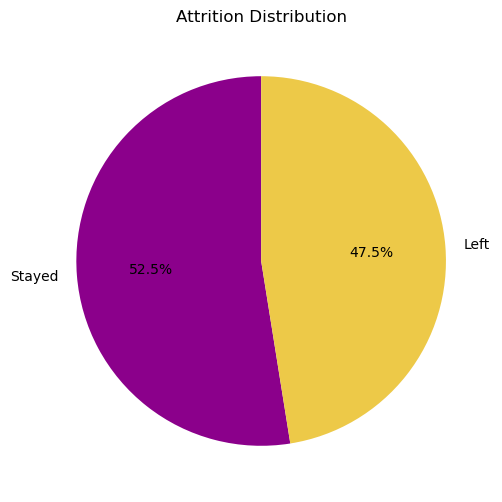

In [25]:
colors = ["#8B008B", "#EDC948"]

df["attrition"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    figsize=(6,6),
    colors=colors,
    startangle=90
)

plt.ylabel("")
plt.title("Attrition Distribution")
plt.show()


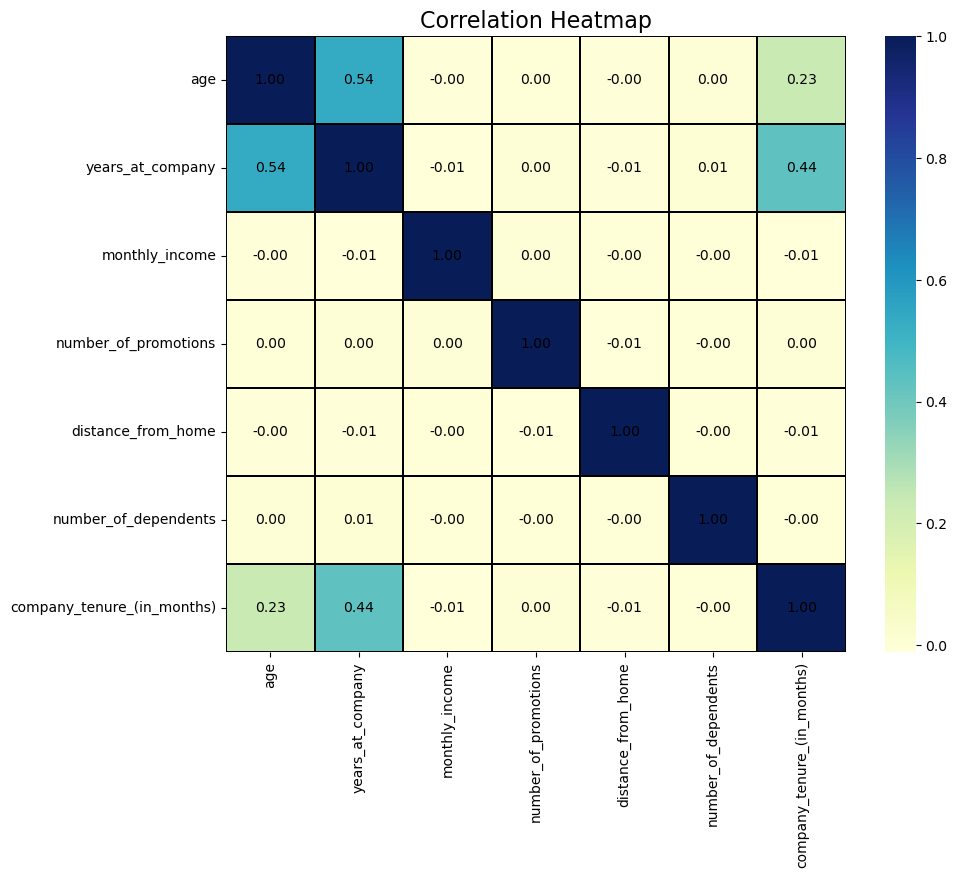

In [26]:
plt.figure(figsize=(10,8))

numeric_data = df.select_dtypes(include=np.number)

sns.heatmap(
    numeric_data.corr(),
    annot=True,
    cmap="YlGnBu",     
    linewidths=0.10,
    linecolor="black",
    fmt=".2f",
    annot_kws={"size":10, "color":"black"}
)

plt.title("Correlation Heatmap", fontsize=16)
plt.show()

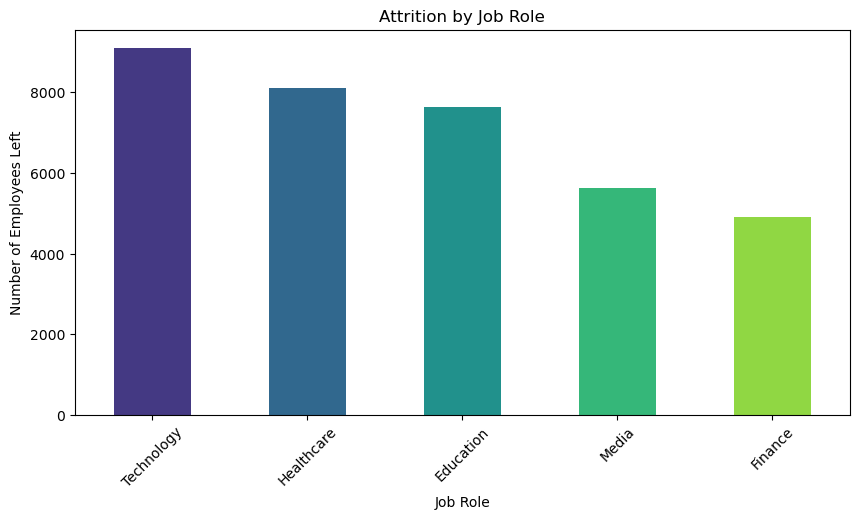

In [27]:
attrition_job = df[df["attrition"]=="Left"]["job_role"].value_counts()
colors = sns.color_palette("viridis", len(attrition_job))

plt.figure(figsize=(10,5))
attrition_job.plot(
    kind="bar",
    color=colors
)

plt.title("Attrition by Job Role")
plt.xlabel("Job Role")
plt.ylabel("Number of Employees Left")
plt.xticks(rotation=45)

plt.show()

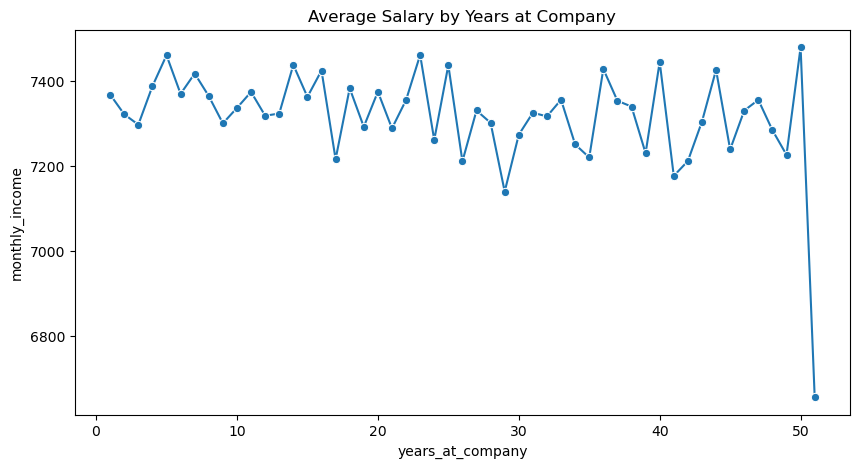

In [28]:
avg_salary = df.groupby("years_at_company")["monthly_income"].mean().reset_index()

plt.figure(figsize=(10,5))
sns.lineplot(
    data=avg_salary,
    x="years_at_company",
    y="monthly_income",
    marker="o"
)

plt.title("Average Salary by Years at Company")
plt.show()

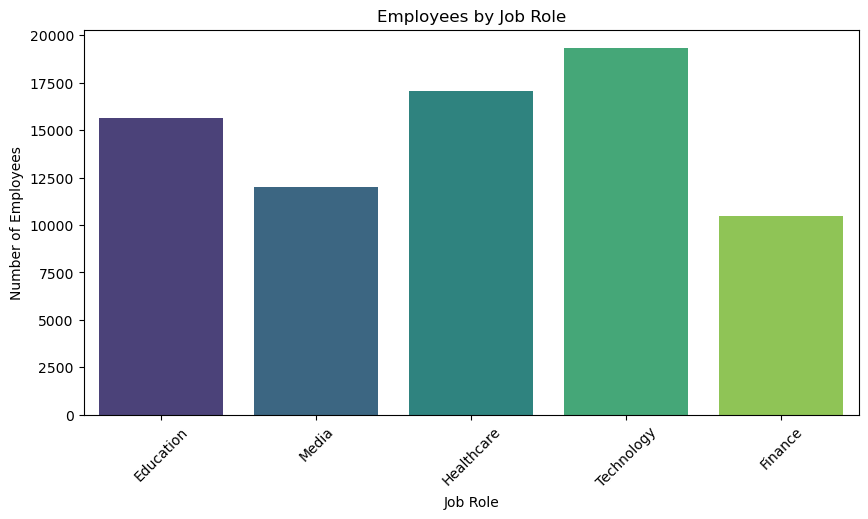

In [29]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x="job_role",
    palette="viridis"
)

plt.xticks(rotation=45)
plt.title("Employees by Job Role")
plt.xlabel("Job Role")
plt.ylabel("Number of Employees")

plt.show()

In [30]:
df_model = df.copy()

df_model.drop(
    ["age_group","salary_category"],
    axis=1,
    inplace=True
)

In [31]:
df_model.columns

Index(['age', 'gender', 'years_at_company', 'job_role', 'monthly_income',
       'work-life_balance', 'job_satisfaction', 'performance_rating',
       'number_of_promotions', 'overtime', 'distance_from_home',
       'education_level', 'marital_status', 'number_of_dependents',
       'job_level', 'company_size', 'company_tenure_(in_months)',
       'remote_work', 'leadership_opportunities', 'innovation_opportunities',
       'company_reputation', 'employee_recognition', 'attrition'],
      dtype='object')

In [32]:
X = df_model.drop("attrition", axis=1)
y = df_model["attrition"]

In [33]:
print(X.shape)
print(y.shape)

(74498, 22)
(74498,)


In [34]:
from sklearn.preprocessing import LabelEncoder

target_encoder = LabelEncoder()

y = target_encoder.fit_transform(y)

In [35]:
categorical_cols = X.select_dtypes(include="object").columns.tolist()

numerical_cols = X.select_dtypes(include=["int64","float64"]).columns.tolist()

print("Categorical Columns: ",categorical_cols)
print("---------------------------------------------------------------")
print("Numerical Columns: ",numerical_cols)

Categorical Columns:  ['gender', 'job_role', 'work-life_balance', 'job_satisfaction', 'performance_rating', 'overtime', 'education_level', 'marital_status', 'job_level', 'company_size', 'remote_work', 'leadership_opportunities', 'innovation_opportunities', 'company_reputation', 'employee_recognition']
---------------------------------------------------------------
Numerical Columns:  ['age', 'years_at_company', 'monthly_income', 'number_of_promotions', 'distance_from_home', 'number_of_dependents', 'company_tenure_(in_months)']


In [36]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(

X,

y,

test_size=0.2,

random_state=42,

stratify=y
)

In [37]:
from sklearn.compose import ColumnTransformer

from sklearn.preprocessing import OneHotEncoder

from sklearn.preprocessing import StandardScaler

preprocessor = ColumnTransformer(

transformers=[

("num",StandardScaler(),numerical_cols),

("cat",OneHotEncoder(handle_unknown="ignore"),categorical_cols)

]

)

In [38]:
preprocessor.fit(X_train)

X_train_transformed = preprocessor.transform(X_train)

print(X_train_transformed.shape)

(59598, 56)


In [39]:
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

import pandas as pd

In [40]:
models = {

    "Logistic Regression": LogisticRegression(max_iter=1000),

    "Decision Tree": DecisionTreeClassifier(random_state=42),

    "Random Forest": RandomForestClassifier(random_state=42),

    "KNN": KNeighborsClassifier(),

    "XGBoost": XGBClassifier(
        random_state=42,
        eval_metric="logloss"
    )

}

In [41]:
results = []

In [42]:
for name, model in models.items():

    try:
        print(f"Training {name}")

        pipeline = Pipeline([
            ("preprocessor", preprocessor),
            ("model", model)
        ])

        pipeline.fit(X_train, y_train)

        y_pred = pipeline.predict(X_test)

        if hasattr(pipeline, "predict_proba"):
            y_prob = pipeline.predict_proba(X_test)[:, 1]
            roc = roc_auc_score(y_test, y_prob)
        else:
            roc = None

        results.append({
            "Model": name,
            "Accuracy": accuracy_score(y_test, y_pred),
            "Precision": precision_score(y_test, y_pred),
            "Recall": recall_score(y_test, y_pred),
            "F1 Score": f1_score(y_test, y_pred),
            "ROC-AUC": roc
        })

    except Exception as e:
        print(f"{name} failed: {e}")

Training Logistic Regression
Training Decision Tree
Training Random Forest
Training KNN
Training XGBoost


In [43]:
results_df = pd.DataFrame(results)

results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.752148,0.762080,0.767825,0.764942,0.841443
1,Decision Tree,0.664430,0.678184,0.687197,0.682661,0.663219
2,Random Forest,0.746107,0.759067,0.756836,0.757950,0.831665
3,KNN,0.671544,0.690736,0.678380,0.684502,0.725534
4,XGBoost,0.751544,0.763818,0.762842,0.763329,0.841020


In [44]:
results_df = results_df.sort_values(
    by="Accuracy",
    ascending=False
)

results_df.reset_index(drop=True, inplace=True)

results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.752148,0.762080,0.767825,0.764942,0.841443
1,XGBoost,0.751544,0.763818,0.762842,0.763329,0.841020
2,Random Forest,0.746107,0.759067,0.756836,0.757950,0.831665
3,KNN,0.671544,0.690736,0.678380,0.684502,0.725534
4,Decision Tree,0.664430,0.678184,0.687197,0.682661,0.663219


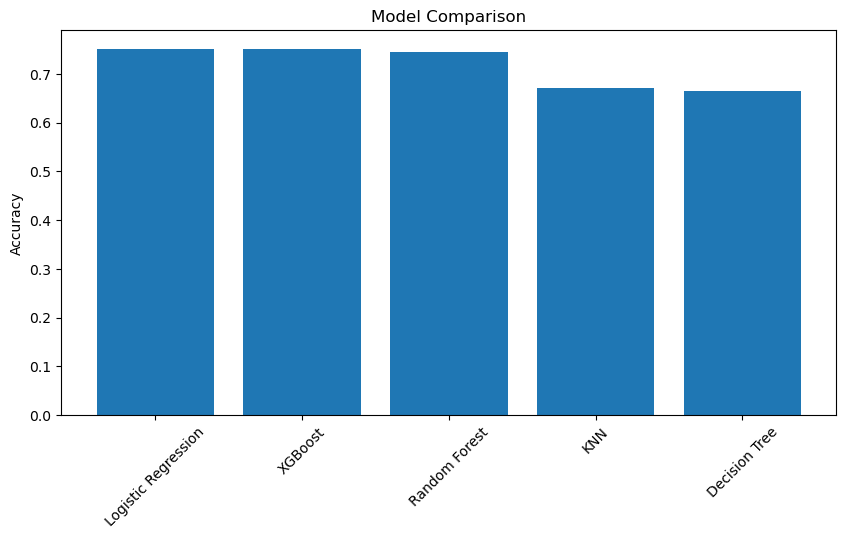

In [45]:
plt.figure(figsize=(10,5))

plt.bar(results_df["Model"], results_df["Accuracy"])

plt.xticks(rotation=45)

plt.ylabel("Accuracy")

plt.title("Model Comparison")

plt.show()

In [46]:
best_model_name = results_df.iloc[0]["Model"]

print("Best Model :", best_model_name)

Best Model : Logistic Regression


In [47]:
best_model = models[best_model_name]

final_pipeline = Pipeline([

    ("preprocessor", preprocessor),

    ("model", best_model)

])

final_pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [48]:
prediction = final_pipeline.predict(X_test)

accuracy = accuracy_score(y_test, prediction)

print("Final Accuracy :", accuracy)

Final Accuracy : 0.7521476510067114


In [49]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    final_pipeline,
    X,
    y,
    cv=5,
    scoring="accuracy"
)

print("Cross Validation Scores :", scores)
print("Average Accuracy :", scores.mean())

Cross Validation Scores : [0.74973154 0.75228188 0.74959732 0.75038593 0.75474864]
Average Accuracy : 0.7513490622090307


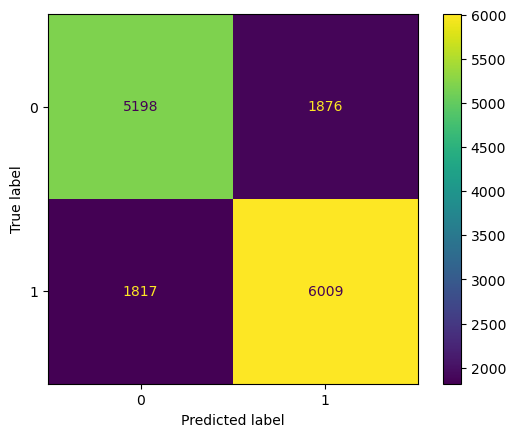

In [50]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred = final_pipeline.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(cm)

disp.plot()

plt.show()

In [51]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.74      0.73      0.74      7074
           1       0.76      0.77      0.76      7826

    accuracy                           0.75     14900
   macro avg       0.75      0.75      0.75     14900
weighted avg       0.75      0.75      0.75     14900



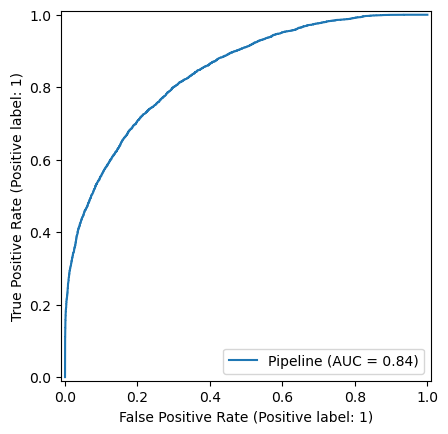

In [52]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(
    final_pipeline,
    X_test,
    y_test
)

plt.show()

In [53]:
import pickle

pickle.dump(
    final_pipeline,
    open("employee_model.pkl", "wb")
)

print("Model Saved Successfully")

Model Saved Successfully


In [54]:
loaded_model = pickle.load(
    open("employee_model.pkl", "rb")
)

prediction = loaded_model.predict(X_test)

print(prediction[:10])

[0 0 1 0 0 0 1 1 1 0]


In [55]:
# Save cleaned dataset
df.to_csv("Employee_Attrition_Cleaned.csv", index=False)